# Part 1

## Flat data and headers

In [ ]:
# Import packgages used to explore/analyse data and plot the profiles
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
# Load ASCII file (adjust delimiter: "\t" for tab, " " for space.)
df = pd.read_csv("for_nitpicker.dat", sep="\t", header=None)

# Assign dataset headers
df.columns = ["Date", "Time", "Depth (m)", "Temperature (°C)", "Salinity(psu)"]

# Save as CSV file
df.to_csv("for_nitpicker.dat.csv", index=False)


In [5]:
# Print out dataset
print(df)

           Date   Time  Depth (m)  Temperature (°C)  Salinity(psu)
0    11/29/2008  06:52          5             28.97          35.21
1    11/29/2008  06:52          6             28.98          35.21
2    11/29/2008  06:52          7             28.99          35.21
3    11/29/2008  06:52          8             28.96          35.21
4    11/29/2008  06:52          9             28.99          35.21
..          ...    ...        ...               ...            ...
991  11/29/2008  06:52        996              6.13          34.85
992  11/29/2008  06:52        997              6.13          34.85
993  11/29/2008  06:52        998              6.12          34.85
994  11/29/2008  06:52        999              6.12          34.85
995  11/29/2008  06:52       1000              6.11          34.85

[996 rows x 5 columns]


# Part 2

## Temperature and Salinity Profiles

In [10]:
# Print columns for preview prior to plotting
print(df.columns.tolist())

['Date', 'Time', 'Depth (m)', 'Temperature (°C)', 'Salinity(psu)']


Index(['Date', 'Time', 'Depth (m)', 'Temperature (°C)', 'Salinity(psu)'], dtype='str')


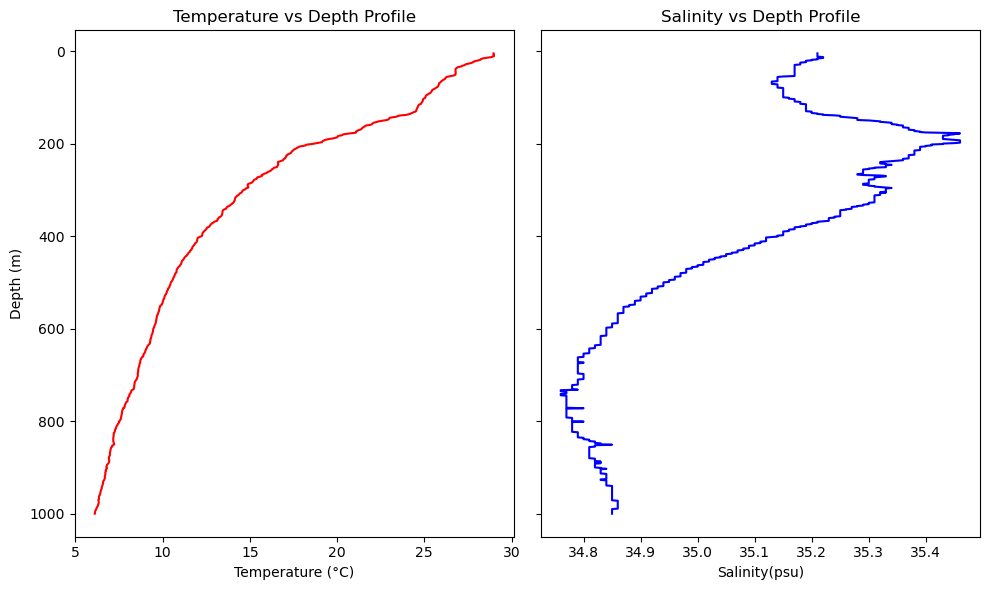

In [11]:
# Load the renamed file (ASCII converted to CSV)
df = pd.read_csv("for_nitpicker.dat.csv")

# Create two subplots side by side, sharing the y-axis
fig, (ax1, ax2) = plt.subplots(1, 2, sharey=True, figsize=(10, 6))

# Plotting the Temperature profile
ax1.plot(df['Temperature (°C)'], df['Depth (m)'], color='red', linestyle="-")
ax1.set_xlabel('Temperature (°C)')
ax1.set_ylabel('Depth (m)')
ax1.set_title('Temperature vs Depth Profile')

# Plotting the Salinity profile
ax2.plot(df['Salinity(psu)'], df['Depth (m)'], color='blue', linestyle="-")
ax2.set_xlabel('Salinity(psu)')
ax2.set_title('Salinity vs Depth Profile')

# Invert y-axis so depth increases downward
ax1.invert_yaxis()

# Use matplotlib.pyplot to show the plot
plt.tight_layout()
plt.show()


# Part 3

## Time series

In [26]:
# Import the necessary packages used to analyse data, handle arrays, and plot the 
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

#### Part 3.1: Loading and analysing dataset

In [34]:
# Load the CSV file with TIME_SERVER as the time index
df = pd.read_csv(
    "SAA2_WC_2017_metocean_10min_avg.csv",
    parse_dates=["TIME_SERVER", "TIME_GPS"]
)
print(df)

        id         TIME_SERVER            TIME_GPS  LATITUDE N_S  LONGITUDE  \
0     1256 2017-06-28 17:10:00 2026-05-07 17:09:58  3428.595   S   1819.447   
1     1257 2017-06-28 17:20:00 2026-05-07 17:19:58  3430.443   S   1820.241   
2     1258 2017-06-28 17:30:00 2026-05-07 17:29:59  3432.261   S   1821.118   
3     1259 2017-06-28 17:40:00 2026-05-07 17:40:02  3434.121   S   1821.882   
4     1260 2017-06-28 17:50:00 2026-05-07 17:49:58  3435.981   S   1822.673   
...    ...                 ...                 ...       ...  ..        ...   
2197  3453 2017-07-13 23:20:00 2026-05-07 23:20:02  3354.136   S   1825.556   
2198  3454 2017-07-13 23:30:00 2026-05-07 23:30:03  3354.136   S   1825.556   
2199  3455 2017-07-13 23:40:00 2026-05-07 23:40:03  3354.136   S   1825.556   
2200  3456 2017-07-13 23:50:00 2026-05-07 23:50:03  3354.137   S   1825.556   
2201  3457 2017-07-14 00:00:00 2026-05-07 00:00:03  3354.137   S   1825.556   

     E_W  HUMIDITY  BAROMETER  AIR_TEMPERATURE  WIN

C:\Users\yibanathima\AppData\Local\Temp\ipykernel_11076\2888731819.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv(


In [35]:
# Check missing values
print("\nMissing values per column:")
print(df.isna().sum())


Missing values per column:
id                   0
TIME_SERVER          0
TIME_GPS           225
LATITUDE           225
N_S                225
LONGITUDE          225
E_W                225
HUMIDITY           225
BAROMETER          225
AIR_TEMPERATURE    225
WIND_SPEED_REL     225
WIND_SPEED_TRUE    228
WIND_DIR_REL       225
WIND_DIR_TRUE      228
PAR                226
TSG_SALINITY       339
TSG_TEMP           339
dtype: int64


In [37]:
# Set TIME_SERVER as the index
df = df.set_index("TIME_SERVER")

#### Part 3.2: Temperature time series plot

In [39]:
# Select data from departure until July 4th inclusive
end_date = "2017-07-04"
df_sel = df.loc[:end_date]

In [40]:
print("\nSelected data range (head and tail):")
print(df_sel.head())
print(df_sel.tail())


Selected data range (head and tail):
                       id            TIME_GPS  LATITUDE N_S  LONGITUDE E_W  \
TIME_SERVER                                                                  
2017-06-28 17:10:00  1256 2026-05-07 17:09:58  3428.595   S   1819.447   E   
2017-06-28 17:20:00  1257 2026-05-07 17:19:58  3430.443   S   1820.241   E   
2017-06-28 17:30:00  1258 2026-05-07 17:29:59  3432.261   S   1821.118   E   
2017-06-28 17:40:00  1259 2026-05-07 17:40:02  3434.121   S   1821.882   E   
2017-06-28 17:50:00  1260 2026-05-07 17:49:58  3435.981   S   1822.673   E   

                     HUMIDITY  BAROMETER  AIR_TEMPERATURE  WIND_SPEED_REL  \
TIME_SERVER                                                                 
2017-06-28 17:10:00      73.2     1.0175             12.5             6.7   
2017-06-28 17:20:00      65.2     1.0174             12.7             6.3   
2017-06-28 17:30:00      68.0     1.0179             12.8             7.4   
2017-06-28 17:40:00      68.0 

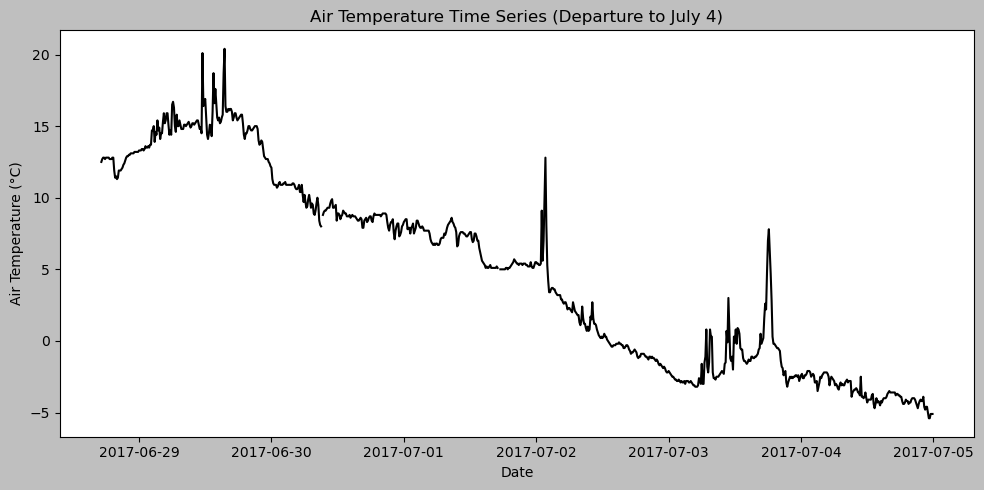

In [42]:
# Plot time series of temperature
plt.style.use("grayscale")
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df_sel.index, df_sel["AIR_TEMPERATURE"], color="black", linestyle="-")
ax.set_xlabel("Date")
ax.set_ylabel("Air Temperature (°C)")
ax.set_title("Air Temperature Time Series (Departure to July 4)")
plt.tight_layout()
plt.savefig("temperature_timeseries.png", dpi=300)
plt.show()


#### Part 3.3 Salinity distribution using a histogram plot 

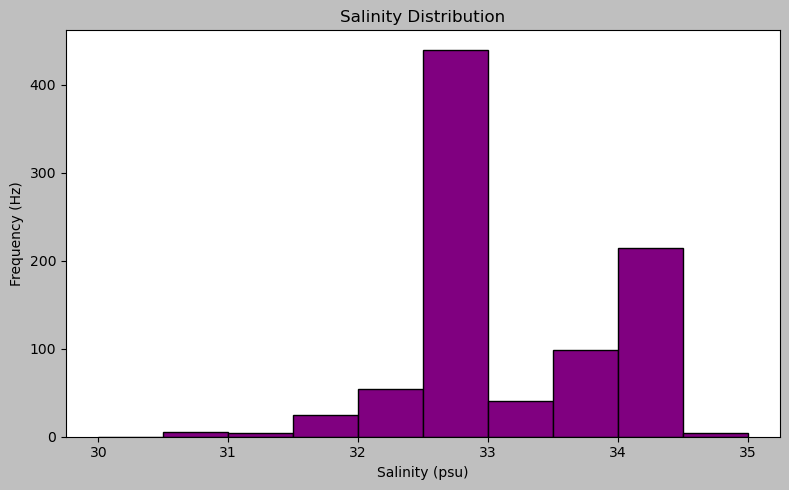

In [47]:
# Plot histogram of salinity distribution
fig, ax = plt.subplots(figsize=(8, 5))
bins = np.arange(30, 35.5, 0.5)  # bins of 0.5 psu between 30 and 35
ax.hist(df_sel["TSG_SALINITY"].dropna(), bins=bins, color="purple", edgecolor="black")
ax.set_xlabel("Salinity (psu)")
ax.set_ylabel("Frequency (Hz)")
ax.set_title("Salinity Distribution")
plt.tight_layout()
plt.savefig("salinity_histogram.png", dpi=300)
plt.show()


#### Part 3.4: Statistics calculations  

In [48]:
# Calculate statistics for temperature and salinity
stats = pd.DataFrame({
    "Mean": [df_sel["AIR_TEMPERATURE"].mean(), df_sel["TSG_SALINITY"].mean()],
    "Std Dev": [df_sel["AIR_TEMPERATURE"].std(), df_sel["TSG_SALINITY"].std()],
    "IQR": [
        df_sel["AIR_TEMPERATURE"].quantile(0.75) - df_sel["AIR_TEMPERATURE"].quantile(0.25),
        df_sel["TSG_SALINITY"].quantile(0.75) - df_sel["TSG_SALINITY"].quantile(0.25)
    ]
}, index=["Air Temperature", "Salinity"])

print("\nStatistics Table:")
print(stats)


Statistics Table:
                      Mean   Std Dev        IQR
Air Temperature   4.878271  6.692847  11.675000
Salinity         33.110553  1.140150   1.272575


#### Part 3.5 Wind speed and Air temperature plots

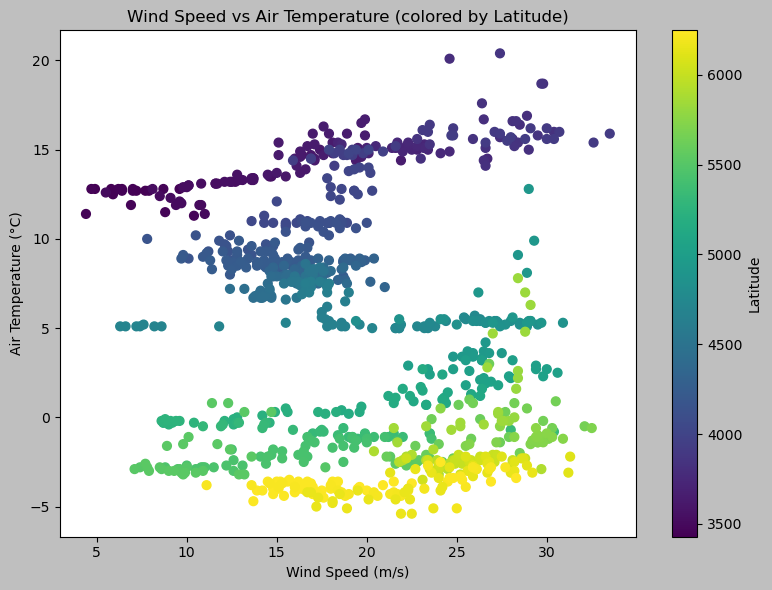

In [49]:
# Scatter plot of wind speed vs air temperature, colored by latitude
fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(df_sel["WIND_SPEED_TRUE"], df_sel["AIR_TEMPERATURE"],
                c=df_sel["LATITUDE"], cmap="viridis", s=40)
ax.set_xlabel("Wind Speed (m/s)")
ax.set_ylabel("Air Temperature (°C)")
ax.set_title("Wind Speed vs Air Temperature (colored by Latitude)")
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Latitude")
plt.tight_layout()
plt.savefig("wind_vs_airtemp.png", dpi=300)
plt.show()
